```{index} single: solver; HiGHS
```
```{index} pandas dataframe
```
```{index} sample average approximation
```
```{index} stochastic optimization
```
```{index} chance constraints
```
```{index} mutable parameters
```

# 9.4 Economic dispatch in renewable energy systems using chance constraints

## Preamble: Install Pyomo and a solver

This notebook uses HiGHS to solve a mixed-integer linear optimization (MILO) model. On Google Colab, the following cell installs Pyomo and the HiGHS Python interface. Elsewhere, these packages must already be installed. No commercial solver licence is required.

The scenario indicators below are binary: a continuous nonlinear solver such as Ipopt would relax their integrality and would not enforce the stated limit on the number of violated scenarios.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install pyomo highspy -q

import pyomo.environ as pyo

solver = "appsi_highs"
SOLVER = pyo.SolverFactory(solver)
assert SOLVER.available(), f"Solver {solver} is not available."

## Problem description

In this notebook, we will explore the applications of chance constraints to an area where high-probability guarantees on the system's functioning are required - the _economic dispatch (ED)_ problem.

The problem considers the short-term determination of the optimal production of energy to meet all energy demands. Let $V$ denote a set of nodes, each of which is representing cities, industrial districts, power generators, or combinations of these. Each node $i \in V$ may have:
- a certain energy demand $d_i \geq 0$; 
- a power generator whose energy production needs to be between $p_i^{min}$ and $p_i^{max}$ units of power. The cost of producing one unit of power at node $i$ is given by a variable cost $c_i \geq 0$. 
Importantly, not all the nodes have demand and generation, more specifically it is possible for a node to have only generation or only demand.

The goal is to determine for each node $i \in V$ the optimal production level $p_i$, such that 
- the total energy demand is met
- no production limits are exceeded
- the total energy production costs are minimized. 

If we fully control the energy production and the customer demand is known, we can formulate the problem as the following linear optimization (LO) problem:

$$
\begin{align}
\begin{array}{llll}
\min        & \sum_{i \in V} c_i p_i\\
\text{s.t.} & \sum_{i \in V} p_i = \sum_{i \in V} d_i,\\
& p_{i}^{min} \leq p_{i} \leq p_{i}^{max} & \forall i \in V.
\end{array}
\end{align}
$$

Now, assume that we have built several offshore wind turbines. These wind turbines combined together produce a random non-negative amount of extra energy, denoted by $\omega$. For a fixed value of $\omega$, the optimization problem to be solved is thus to 'fill in' to the remaining energy demand not satisfied by wind power:

$$
\begin{align}
\begin{array}{llll}
\min        & \sum_{i \in V} c_i p_i\\
\text{s.t.} & \omega + \sum_{i \in V} p_i = \sum_{i \in V} d_i,\\
& p_{i}^{min} \leq p_{i} \leq p_{i}^{max} & \forall i \in V.
\end{array}
\end{align}
$$

The problem, however, is that $\omega$ is a random variable and is typically not fully known before the generation levels $p_i$ of conventional generators have to be set. Because of stochastic fluctuations in wind power generation, the ED problem is best modeled as a stochastic optimization problem. The intermittency of wind generation makes it almost impossible to perfectly balance supply and demand on a real-time basis, but in practice there is some tolerance for error, i.e., certain degree of mismatch between supply and demand can be easily adjusted for. 

To formulate the problem under this assumption, let us denote by:
- $\Delta \geq 0$ the tolerance of the absolute power mismatch between supply and demand;
- $\varepsilon \in [0,1]$ is the maximum probability we allow for supply to deviate from demand by more than $\Delta$;
- $\omega$ the non-negative random variable describing the total power production of offshore wind turbines.

In this setting, instead of requiring that the supply and demand are matched perfectly, we require that the absolute difference remains below power threshold $\Delta$ using the following chance constraint:

$$
\begin{align}
  \mathbb{P} \Big ( \Big | \omega + \sum_{i \in V } p_i  - \sum_{i \in V} d_i \Big | \leq \Delta \Big) \geq 1 - \varepsilon.
\end{align}
$$

We retain this **joint** chance constraint: a scenario is successful only when both the upper and lower mismatch limits hold. Requiring each one-sided limit separately with probability $1-\varepsilon$ would instead allow a total violation probability of up to $2\varepsilon$ (capped at one), and would therefore be a relaxation.

We use sample average approximation (SAA) with 500 historical wind production outcomes. The MILO below requires at least a fraction $1-\varepsilon$ of these outcomes to satisfy both limits. This is an empirical guarantee on the supplied sample, not a guarantee for unseen wind outcomes.

## Data import

We first import the necessary packages and define a function that reads all the necessary node and wind production random sample data.

In [2]:
import pyomo.environ as pyo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pathlib import Path


def read_economic_dispatch_data():
    # Prefer the data shipped with a local checkout; use the same snapshot on Colab.
    data_dir = Path("data")
    if not (data_dir / "discrete_wind.csv").is_file():
        data_dir = Path("notebooks/09/data")
    base_url = (
        "https://raw.githubusercontent.com/mobook/MO-book/"
        "44c737a7ef000779b9af34efbfd72140cc95b508/notebooks/09/data/"
    )

    def read_csv(name, **kwargs):
        source = data_dir / name
        return pd.read_csv(source if source.is_file() else base_url + name, **kwargs)

    nodes_df = read_csv("nodes.csv", index_col=0)[
        ["node_id", "d", "p_min", "p_max", "c_var"]
    ]
    wind_production_samples_df = read_csv("discrete_wind.csv").T
    nodes = nodes_df.set_index("node_id").T.to_dict()
    wind_production_samples = [
        sum(d.values()) for d in wind_production_samples_df.to_dict().values()
    ]
    return nodes, wind_production_samples


nodes, wind_production_samples = read_economic_dispatch_data()

The wind production samples can be accessed through the `wind_production_samples` variable - a list of 500 equiprobable outcomes for the wind generation.

In [4]:
wind_production_samples[4]  # fifth outcome

196.94632359541376

Let us take a look into the wind production data, including a Kernel Density Estimate. 
We see that is has two modes. 
This [paper](https://link.springer.com/article/10.1007/s40565-015-0172-5) explains what one could do with this.

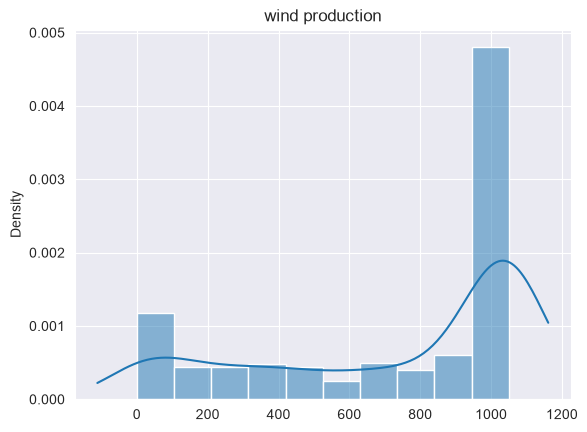

In [5]:
sns.set_style("darkgrid")
sns.histplot(
    wind_production_samples, kde=True, stat="density", kde_kws=dict(cut=1)
).set_title("wind production")
plt.show()

The `nodes` dictionary contains for every $i \in V$ information about $p_i^{min}$, $p_i^{max}$, $c_i$, $d_i$. In our dataset, there is a clear separation of the nodes into nodes that only consume power, and nodes that only produce power, which can be seen by inspecting the node properties.

In [6]:
nodes[0]  # first node properties

{'d': 44.23034433319671, 'p_min': 0.0, 'p_max': 0.0, 'c_var': 0.0}

Let us now provide some locations to our producers and consumers and visualize the data, using bubbles proportional to the size of demand (for consumers) and maximum generation capacity (for producers).

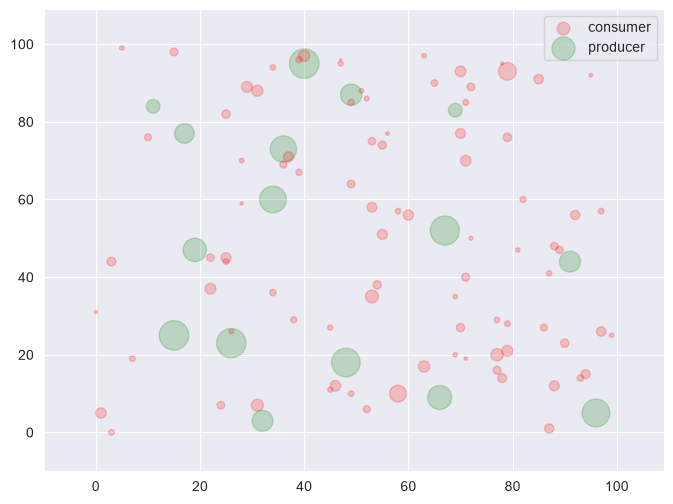

In [7]:
df_nodes = pd.DataFrame.from_dict(nodes, orient="index")
df_nodes["type"] = "consumer"
df_nodes.loc[df_nodes.p_max > 0, "type"] = "producer"
np.random.seed(2023)
df_nodes["x"] = np.random.randint(0, 100, len(nodes))
df_nodes["y"] = np.random.randint(0, 100, len(nodes))
df_nodes["size"] = df_nodes[["d", "p_max"]].max(axis=1)


def ShowInstance(df_nodes):
    # Define the size of the figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Set the scales of the x and y axes
    ax.set_xlim([min(df_nodes["x"]) - 10, max(df_nodes["x"]) + 10])
    ax.set_ylim([min(df_nodes["y"]) - 10, max(df_nodes["y"]) + 10])

    # Create a scatter plot with bubbles proportional to size
    # ax.scatter(df_nodes['x'], df_nodes['y'], s=df_nodes['size']*1)
    for (category, group), z, color in zip(
        df_nodes.groupby("type"), [2, 1], ["red", "green"]
    ):
        ax.scatter(
            group.x,
            group.y,
            s=group["size"] * 1,
            label=category,
            alpha=0.2,
            zorder=z,
            color=color,
        )
        if "sol" in group:
            ax.scatter(
                group.x,
                group.y,
                s=group["sol"] * 1,
                label=None,
                alpha=1,
                zorder=z,
                color=color,
            )

    plt.legend()
    plt.show()


ShowInstance(df_nodes)

## MILO reformulation for the chance-constrained ED problem

For each of the $N$ equiprobable wind outcomes, introduce one binary variable $u_j$. When $u_j=0$, both mismatch limits must hold. When $u_j=1$, both limits may be relaxed. The shared indicator therefore counts a scenario only once, whether its mismatch is too high or too low. We allow at most $\lfloor\varepsilon N\rfloor$ such scenarios.

Writing $D=\sum_{i\in V}d_i$, the resulting MILO is

$$
\begin{aligned}
\min\quad & \sum_{i\in V}c_i p_i\\
\text{s.t.}\quad
& \omega_j+\sum_{i\in V}p_i-D \leq \Delta+M_j^+u_j
&& j=1,\ldots,N,\\
& \omega_j+\sum_{i\in V}p_i-D \geq -\Delta-M_j^-u_j
&& j=1,\ldots,N,\\
& \sum_{j=1}^N u_j\leq\varepsilon N,\\
& p_i^{min}\leq p_i\leq p_i^{max} && i\in V,\\
& u_j\in\{0,1\} && j=1,\ldots,N.
\end{aligned}
$$

Separate nonnegative big-$M$ constants for the two inequalities follow directly from the generation bounds:

$$
\begin{aligned}
M_j^+ &= \max\left\{0,\ \omega_j+\sum_{i\in V}p_i^{max}-D\right\},\\
M_j^- &= \max\left\{0,\ D-\omega_j-\sum_{i\in V}p_i^{min}\right\}.
\end{aligned}
$$

These constants already deactivate the corresponding inequalities at $\Delta=0$ when $u_j=1$. Increasing $\Delta$ only relaxes the inequalities, so the same constants remain valid throughout the sensitivity analysis. Only $\varepsilon$ and $\Delta$ need to be mutable parameters.

The solver helper loads values only after an optimal solve. Infeasible parameter combinations return `False`; any other termination condition raises an error rather than being silently omitted from the plots.

In [8]:
def economic_dispatch(nodes, samples, eps, Delta):
    if len(samples) == 0:
        raise ValueError("At least one wind production sample is required.")

    model = pyo.ConcreteModel("Economic Dispatch")
    model.n = pyo.Param(initialize=len(samples))
    model.eps = pyo.Param(mutable=True, initialize=eps, within=pyo.UnitInterval)
    model.Delta = pyo.Param(
        mutable=True, initialize=Delta, within=pyo.NonNegativeReals
    )
    model.N = pyo.Set(initialize=range(len(samples)))
    model.nodes = pyo.Set(initialize=nodes.keys())

    demand = sum(data["d"] for data in nodes.values())
    min_supply = sum(data["p_min"] for data in nodes.values())
    max_supply = sum(data["p_max"] for data in nodes.values())
    model.M_plus = pyo.Param(
        model.N, initialize=lambda m, j: max(0, samples[j] + max_supply - demand)
    )
    model.M_minus = pyo.Param(
        model.N, initialize=lambda m, j: max(0, demand - samples[j] - min_supply)
    )
    model.p = pyo.Var(
        model.nodes,
        domain=pyo.NonNegativeReals,
        bounds=lambda m, i: (nodes[i]["p_min"], nodes[i]["p_max"]),
    )
    model.u = pyo.Var(model.N, domain=pyo.Binary)

    @model.Objective(sense=pyo.minimize)
    def objective(m):
        return sum(nodes[i]["c_var"] * m.p[i] for i in m.nodes)

    @model.Constraint(model.N)
    def supply_demand_leq(m, j):
        mismatch = samples[j] + sum(m.p[i] for i in m.nodes) - demand
        return mismatch <= m.Delta + m.M_plus[j] * m.u[j]

    @model.Constraint(model.N)
    def supply_demand_geq(m, j):
        mismatch = samples[j] + sum(m.p[i] for i in m.nodes) - demand
        return mismatch >= -m.Delta - m.M_minus[j] * m.u[j]

    @model.Constraint()
    def success_probability(m):
        return sum(m.u[j] for j in m.N) <= m.eps * m.n

    return model


def solve_dispatch(model):
    results = SOLVER.solve(model, load_solutions=False)
    if pyo.check_optimal_termination(results):
        model.solutions.load_from(results)
        return True
    if results.solver.termination_condition == pyo.TerminationCondition.infeasible:
        return False
    raise RuntimeError(
        f"Dispatch solve terminated with {results.solver.termination_condition}"
    )

For demonstration purposes, we solve the model for $\varepsilon=0.20$ and $\Delta=1000$. Thus at most 100 of the 500 wind outcomes may violate the joint mismatch limit. We report both the production cost and the actual number of sample violations, checked with a numerical tolerance of $10^{-5}$.

In [9]:
eps = 0.20
Delta = 1000
model = economic_dispatch(nodes, wind_production_samples, eps, Delta)
if not solve_dispatch(model):
    raise ValueError("The demonstration dispatch problem is infeasible.")

sum_production = sum(pyo.value(model.p[i]) for i in model.nodes)
sum_demand = sum(data["d"] for data in nodes.values())
tolerance = 1e-5
mismatches = np.asarray(wind_production_samples) + sum_production - sum_demand
violations = np.count_nonzero(np.abs(mismatches) > Delta + tolerance)
assert violations <= eps * len(wind_production_samples) + tolerance
assert all(abs(pyo.value(u) - round(pyo.value(u))) <= tolerance for u in model.u.values())
print(f"Total energy demand: {sum_demand:.3f}")
print(f"Total optimal energy production: {sum_production:.3f}")
print(f"Total energy production cost: {model.objective():.3f}")
print(f"Joint mismatch violations: {violations} / {len(wind_production_samples)}")

Total energy demand: 3007.112
Total optimal energy production: 1733.393
Total energy production cost: 7850.601
Joint mismatch violations: 100 / 500


## Visualizing and understanding the solution

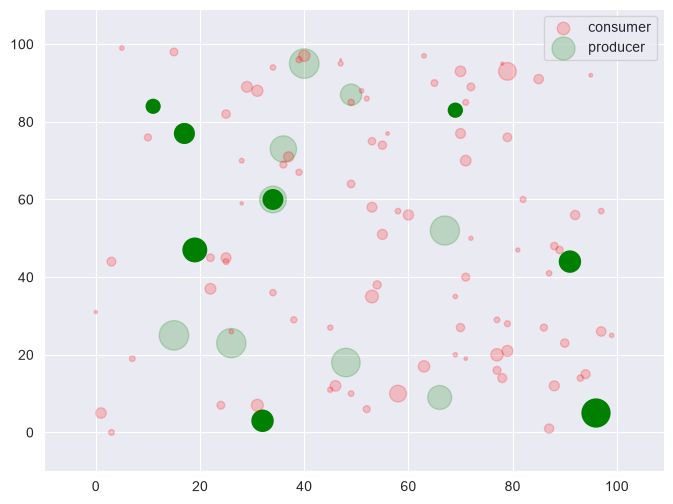

In [10]:
df_nodes["sol"] = model.p.extract_values()
ShowInstance(df_nodes)

## Sensitivity analysis 
Next, we will study the sensitivity of the optimal solution and value to the different risk guarantee levels - this helps the decision maker find a level that offers the best risk-reward tradeoff. To this end, we solve the same MILO varying the values first of $\varepsilon \in [0, 1]$ (for fixed $\Delta=1000$) and then of $\Delta \in [0, 2000]$ (for fixed $\varepsilon = 0.02$).     

Feasible risk levels: 20 / 20


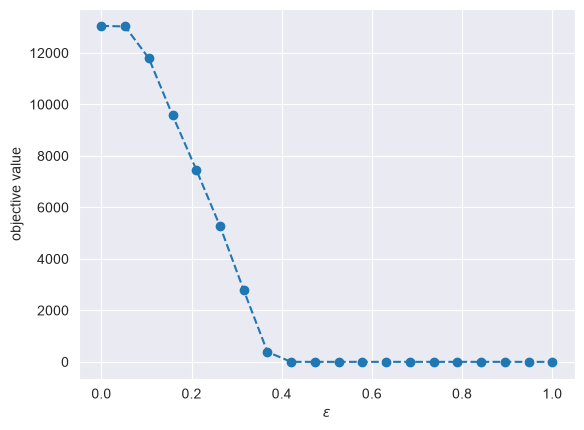

In [11]:
fixed_Delta = 1000

feas_eps = []
feas_objs = []

eps = 0
model = economic_dispatch(nodes, wind_production_samples, eps, fixed_Delta)

for eps in np.linspace(0, 1, num=20):
    model.eps = eps
    if solve_dispatch(model):
        feas_eps.append(eps)
        feas_objs.append(model.objective())

print(f"Feasible risk levels: {len(feas_eps)} / 20")
plt.plot(feas_eps, feas_objs, marker="o", linestyle="--")
plt.xlabel(r"$\varepsilon$")
plt.ylabel("objective value")
plt.show()

Feasible mismatch tolerances: 15 / 20


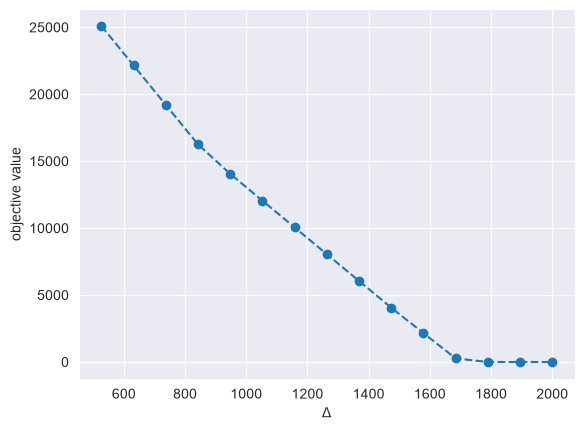

In [12]:
fixed_eps = 0.02

feas_Deltas = []
feas_objs = []

Delta = 0
model = economic_dispatch(nodes, wind_production_samples, fixed_eps, Delta)

for Delta in np.linspace(0, 2000, num=20):
    model.Delta = Delta
    if solve_dispatch(model):
        feas_Deltas.append(Delta)
        feas_objs.append(model.objective())

print(f"Feasible mismatch tolerances: {len(feas_Deltas)} / 20")
plt.plot(feas_Deltas, feas_objs, marker="o", linestyle="--")
plt.xlabel(r"$\Delta$")
plt.ylabel("objective value")
plt.show()

Smaller values of $\varepsilon$ permit fewer sample violations, and smaller values of $\Delta$ require a closer match between supply and demand. Either restriction can make the model infeasible. The plots show only parameter combinations for which an optimal solution was found; the printed counts indicate how many of the 20 tested values were feasible.

As $\varepsilon$ or $\Delta$ increases, the feasible region expands and the minimum cost cannot increase. A flat zero-cost part of the curve does not imply zero generation. This dataset has 1308.236 units of zero-cost generation capacity, including 708.236 units that must be produced because of positive lower bounds. Once the zero-cost generators can satisfy the sample constraints, no positive-cost generation is needed. This differs from obtaining zero cost by relaxing the binary indicators: the latter would not respect the specified scenario violation budget.

These sensitivity results concern the same 500 historical outcomes used in the model. Assessing performance on new outcomes requires a separate validation sample.